In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('youtubers_df.csv')

# Displaying the 1st 5 rows to see if the .csv loaded correctly
df.head()

,Rank,Username,Categories,Suscribers,Country,Visits,Likes,Comments,Links
0,1,tseries,Música y baile,249500000.0,India,86200.0,2700.0,78.0,http://youtube.com/channel/UCq-Fj5jknLsUf-MWSy...
1,2,MrBeast,"Videojuegos, Humor",183500000.0,Estados Unidos,117400000.0,5300000.0,18500.0,http://youtube.com/channel/UCX6OQ3DkcsbYNE6H8u...
2,3,CoComelon,Educación,165500000.0,Unknown,7000000.0,24700.0,0.0,http://youtube.com/channel/UCbCmjCuTUZos6Inko4...
3,4,SETIndia,NaN,162600000.0,India,15600.0,166.0,9.0,http://youtube.com/channel/UCpEhnqL0y41EpW2TvW...
4,5,KidsDianaShow,"Animación, Juguetes",113500000.0,Unknown,3900000.0,12400.0,0.0,http://youtube.com/channel/UCk8GzjMOrta8yxDcKf...


In [6]:
# 1. Data Exploration

print("------------DATA STRUCTURE AND INFO--------------\n")
print(df.info())
print("\n")

print("------------MISSING VALUES PER COLUMN--------------\n")
print(df.isnull().sum())
print("\n")

print("------------OUTLIERS--------------\n")
print(df.describe())

------------DATA STRUCTURE AND INFO--------------

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        1000 non-null   int64  
 1   Username    1000 non-null   str    
 2   Categories  694 non-null    str    
 3   Suscribers  1000 non-null   float64
 4   Country     1000 non-null   str    
 5   Visits      1000 non-null   float64
 6   Likes       1000 non-null   float64
 7   Comments    1000 non-null   float64
 8   Links       1000 non-null   str    
dtypes: float64(4), int64(1), str(4)
memory usage: 70.4 KB
None


------------MISSING VALUES PER COLUMN--------------

Rank            0
Username        0
Categories    306
Suscribers      0
Country         0
Visits          0
Likes           0
Comments        0
Links           0
dtype: int64


------------OUTLIERS--------------

              Rank    Suscribers        Visits         Likes       Comme

### 1. Data Exploration Results

**Dataset Structure:**
* The dataset contains exactly 1000 rows (entries 0 to 999) and 9 columns.
* The data types consist of a mix of `int64` (Rank), `float64` (Suscribers, Visits, Likes, Comments), and `str` (Username, Categories, Country, Links).

**Missing Data:**
* The `Categories` column has 306 missing (null) values. 
* All other columns have exactly 1000 non-null values, meaning they are fully populated. 
* *Note:* While the `Country` column has no standard null values, the initial data preview reveals that some entries are filled with the string "Unknown" (e.g., CoComelon and KidsDianaShow).

**Outliers & Statistical Summary:**
* A review of the descriptive statistics indicates extreme right-skewness in engagement metrics, suggesting significant outliers.
* For instance, the 75th percentile for `Visits` is roughly 865,475, but the maximum value is exponentially higher at over 117.4 million. 
* Similar massive leaps between the 75th percentile and the maximum exist for both `Likes` and `Comments`, indicating that a small handful of top creators receive vastly more engagement than the rest of the top 1000.

-----------TOP CATEGORIES-----------
 Categories
Música y baile               160
Películas, Animación          61
Música y baile, Películas     41
Vlogs diarios                 37
Noticias y Política           36
Name: count, dtype: int64


----------CORRELATION MATRIX------------
             Suscribers     Likes  Comments
Suscribers    1.000000  0.211639  0.036350
Likes         0.211639  1.000000  0.325911
Comments      0.036350  0.325911  1.000000




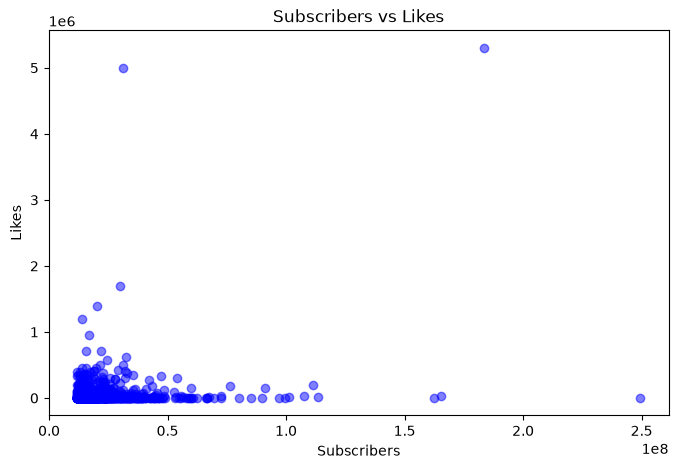

In [9]:
# 2. Trend Analysis

popular_categories = df['Categories'].value_counts()
print("-----------TOP CATEGORIES-----------\n", popular_categories.head())

correlation = df[['Suscribers', 'Likes', 'Comments']].corr()
print("\n\n----------CORRELATION MATRIX------------\n", correlation)
print("\n")

# Scatter plot of Subs v Likes
plt.figure(figsize=(8, 5))
plt.scatter(df['Suscribers'], df['Likes'], alpha=0.5, color='blue')
plt.title('Subscribers vs Likes')
plt.xlabel('Subscribers')
plt.ylabel('Likes')
plt.show()

### 2. Trend Analysis Results

**Most Popular Categories:**
* The most dominant category among the top 1000 streamers is **Música y baile** (Music and Dance) with 160 creators.
* This is followed by **Películas, Animación** (Movies and Animation) with 61 creators, and a hybrid category of **Música y baile, Películas** with 41 creators.
* This trend indicates that highly replayable, globally appealing entertainment (like music videos and animation) dominates the highest echelons of YouTube.

**Correlation Analysis:**
* **Subscribers vs. Likes (0.21):** There is a weak positive correlation. This indicates that having a massive, accumulated subscriber base does not automatically guarantee proportionately high like counts on active videos. 
* **Subscribers vs. Comments (0.04):** There is practically zero correlation between the number of subscribers and the number of comments. 
* **Likes vs. Comments (0.33):** There is a moderate positive correlation here. This is expected, as viewers who are driven to actively engage with a video by "liking" it are inherently more likely to also leave a comment.

**Visualizing the Trend (Scatter Plot):**
* The scatter plot of *Subscribers vs Likes* visually confirms the weak mathematical correlation. 
* The vast majority of top creators are clustered heavily near the bottom-left of the chart, meaning "average" top-tier channels have a baseline level of subscribers and likes.
* The chart clearly highlights extreme outliers: for example, one data point on the far right has roughly 250 million subscribers but relatively low likes. Meanwhile, another point near 180 million subscribers has an astronomical like count (over 5 million). These massive variances perfectly illustrate why subscriber count is not a reliable predictor of video likes.

In [16]:
# 3. Audience Study

country_dist = df['Country'].value_counts()
print("-----------------TOP COUNTRIES(Distribution of streamers)-----------------\n", country_dist.head())
print("\n")

regional_prefs = df.groupby('Country')['Categories'].value_counts().unstack().fillna(0)
print("\n------------------REGIONAL PREFERENCES--------------------\n", regional_prefs.head())

-----------------TOP COUNTRIES(Distribution of streamers)-----------------
 Country
Estados Unidos    293
India             241
Unknown           171
Brasil             64
México             58
Name: count, dtype: int64



------------------REGIONAL PREFERENCES--------------------
 Categories      ASMR  ASMR, Comida y bebida  Animación  Animación, Humor  \
Country                                                                    
Arabia Saudita   0.0                    0.0        0.0               0.0   
Argelia          0.0                    0.0        0.0               0.0   
Argentina        0.0                    0.0        1.0               0.0   
Bangladesh       0.0                    0.0        0.0               0.0   
Brasil           0.0                    0.0        3.0               2.0   

Categories      Animación, Humor, Juguetes  Animación, Juguetes  \
Country                                                           
Arabia Saudita                         0.0        

### 3. Audience Study Results

**Distribution of Streamers by Country:**
* The global audience landscape is heavily dominated by two major regions: **Estados Unidos** (United States) with 293 creators and **India** with 241 creators. Together, they make up more than half of the top 1000 dataset.
* **Brasil** (64) and **México** (58) also represent substantial hubs for top-tier content creators.
* *Data Quality Note:* A significant portion of the data—171 channels—is classified under an **"Unknown"** country location. This indicates a limitation in the dataset's tracking or that many creators mask their regional location data.

**Regional Preferences & Category Clustering:**
* The cross-tabulation table shows high sparsity (many `0.0` entries), which is expected because small or emerging markets only have a handful of creators qualifying for the top 1000 across specific niche categories.
* **Regional Insights from the Data Matrix:**
    * **Brasil** shows a highly diversified and dense creator market compared to other Latin American counterparts in the sample. For instance, it boasts 12 creators in *Películas, Animación* (Movies, Animation), 4 in *Películas, Humor*, and 3 in *Animación*. 
    * Smaller markets like **Arabia Saudita** or **Argelia** show highly concentrated listings, appearing only in singular categories (such as 1 creator for Saudi Arabia in *Animación, Videojuegos*). 
* This structure demonstrates that while general entertainment categories cross borders, regional market size heavily impacts how many creators can successfully scale to reach global ranking metrics.

---------------AVERAGE METRICS--------------------
 Suscribers    2.189440e+07
Visits        1.209446e+06
Likes         5.363259e+04
Comments      1.288768e+03
dtype: float64




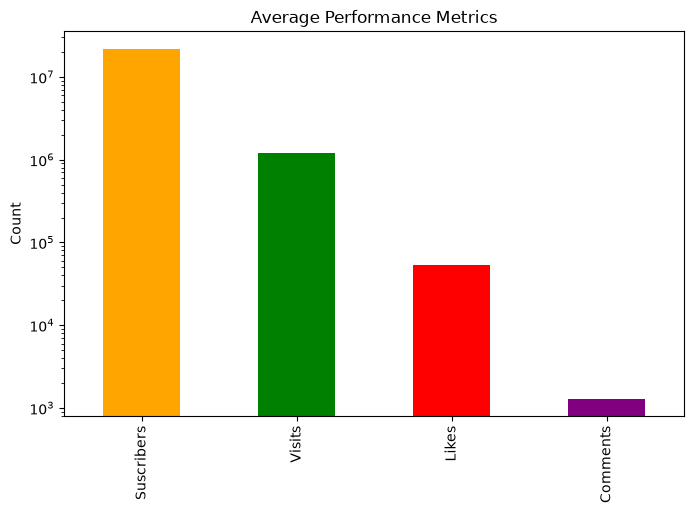

In [18]:
# 4. Performance Metrics

averages = df[['Suscribers', 'Visits', 'Likes', 'Comments']].mean()
print("---------------AVERAGE METRICS--------------------\n", averages)
print("\n")

# bar chart of the above (Using a log scale because Subscribers are much higher than Comments)
averages.plot(kind='bar', figsize=(8, 5), color=['orange', 'green', 'red', 'purple'])
plt.title('Average Performance Metrics')
plt.ylabel('Count')
plt.yscale('log')
plt.show()

### 4. Performance Metrics Results

**Average Metrics Analysis:**
* **Subscribers:** The average top-1000 YouTube creator has an enormous baseline of approximately **21.89 million** subscribers (`2.189e+07`).
* **Visits:** Despite the massive subscriber counts, the average visits (views) per video drop significantly to roughly **1.21 million** (`1.209e+06`). 
* **Likes & Comments:** Active engagement is a fraction of total viewership. The average video receives about **53,600** likes (`5.363e+04`) and just under **1,300** comments (`1.288e+03`).

**Patterns and Anomalies (The Engagement Funnel):**
* **The "Passive Audience" Pattern:** There is a clear, steep funnel effect in the data. On average, only about 5.5% of a channel's total subscriber base actually visits/views a given video. From those viewers, an even smaller fraction actively engages by leaving a like (about 4.4% of visits) or a comment (about 0.1% of visits).
* **Visualization Anomaly (Logarithmic Scale):** In the bar chart, the height difference between "Subscribers" and "Comments" doesn't look as massive as the raw numbers suggest. This is because a **logarithmic scale** (notice the y-axis: $10^3$, $10^5$, $10^7$) was used to visualize the data. If a standard linear scale were used, the "Comments" and "Likes" bars would be completely invisible compared to the 21-million-high "Subscribers" bar. This highlights the extreme numerical disparity between passive subscribers and active engagers.

In [4]:
# 5. Content Categories

category_performance = df.groupby('Categories')[['Suscribers', 'Visits', 'Likes', 'Comments']].mean()

exceptional_categories = category_performance.sort_values(by='Suscribers', ascending=False)
print("-------------------------EXCEPTIONAL CATEGORIES--------------------------\n\n", exceptional_categories.head())

-------------------------EXCEPTIONAL CATEGORIES--------------------------

                           Suscribers        Visits          Likes     Comments
Categories                                                                    
Juguetes                3.788000e+07  7.005100e+05    5290.200000     2.800000
Películas, Videojuegos  3.325000e+07  6.940375e+05   48083.375000  1569.500000
Animación, Juguetes     2.937586e+07  5.254483e+05    2653.068966     0.517241
Videojuegos, Humor      2.876471e+07  1.023968e+07  420511.764706  4827.058824
Música y baile          2.683688e+07  3.743881e+05   17405.681250  1998.931250


### 5. Content Categories Results

**Exceptional Categories by Subscriber Volume:**
* When grouping by category and sorting by average subscribers, children's content and gaming dominate the very top. 
* The **Juguetes** (Toys) category ranks first, averaging an astonishing **37.88 million** subscribers (`3.788e+07`). 
* It is followed by **Películas, Videojuegos** (Movies, Video Games) with **33.25 million** subscribers and **Animación, Juguetes** (Animation, Toys) with **29.37 million** subscribers.

**The Engagement Disconnect (Passive vs. Active Audiences):**
* **Passive Audiences:** While *Juguetes* and *Animación, Juguetes* have the highest subscriber counts, their engagement metrics are drastically lower. For instance, despite having nearly 38 million subscribers, the *Juguetes* category averages only 2.8 comments per video. This strongly implies a passive, likely very young audience that watches but does not actively interact (or channels where comments are strictly disabled by platform policies for minors).
* **Exceptional Performance Metrics:** The true standout category in terms of overall performance is **Videojuegos, Humor** (Video Games, Humor). While it ranks fourth in average subscribers (~28.7 million), it completely dominates all active engagement metrics. It averages over **10.2 million visits**, **420,000 likes**, and **4,800 comments** per video. 
* **Conclusion:** If we define "exceptional performance" purely by subscriber count, toy and animation channels win. However, if we define it by high user engagement and active viewership, the gaming and comedy hybrid category is by far the most exceptionally performing niche on the platform.

### 6. Brands and Collaborations
**Important Clarification:**
* The provided dataset does not contain specific data points for brand collaborations or marketing campaigns. However, assuming that streamers with higher engagement (Visits, Likes, Comments) offer higher visibility, we can infer that those in the top percentiles of these metrics are the most likely candidates for brand deals

In [8]:
# 7. Benchmarking

# Calculate the means
mean_subs = df['Suscribers'].mean()
mean_visits = df['Visits'].mean()
mean_likes = df['Likes'].mean()
mean_comments = df['Comments'].mean()

# Filter streamers who are strictly ABOVE average in ALL metrics
above_average_streamers = df[
    (df['Suscribers'] > mean_subs) &
    (df['Visits'] > mean_visits) &
    (df['Likes'] > mean_likes) &
    (df['Comments'] > mean_comments)
]

print(f"Number of streamers above average in all metrics: {len(above_average_streamers)}")
print("\nTOP PERFORMERS:\n", above_average_streamers[['Username', 'Categories', 'Suscribers']].head(10))

Number of streamers above average in all metrics: 38

TOP PERFORMERS:
            Username              Categories   Suscribers
1           MrBeast      Videojuegos, Humor  183500000.0
5         PewDiePie  Películas, Videojuegos  111500000.0
26      dudeperfect             Videojuegos   59700000.0
34      TaylorSwift          Música y baile   54100000.0
39      JuegaGerman    Películas, Animación   48600000.0
43         A4a4a4a4        Animación, Humor   47300000.0
58        Mikecrack    Películas, Animación   43400000.0
62   KimberlyLoaiza          Música y baile   42100000.0
64  luisitocomunica                     NaN   41100000.0
70      JessNoLimit    Películas, Animación   39600000.0


### 7. Benchmarking Results

**The Elite Tier (Above Average Across All Metrics):**
* Out of the dataset of 1000 top YouTube channels, only **38 streamers** (3.8%) managed to score strictly above the mathematical average in every single metric (Subscribers, Visits, Likes, and Comments). 
* This extremely low percentage reinforces our earlier statistical findings regarding extreme outliers: a tiny fraction of "mega-creators" pull the averages so incredibly high that 96.2% of the world's top 1000 channels cannot beat the average across the board.

**Top-Performing Content Creators:**
* **MrBeast** and **PewDiePie** stand at the absolute top of this elite benchmarking list, boasting 183.5 million and 111.5 million subscribers respectively, alongside massive engagement numbers.
* Consistent with our findings in the Content Categories section, the top 10 benchmarked creators are heavily concentrated in high-engagement entertainment categories. Variations of Video Games, Movies, Animation, and Humor make up the vast majority of this list.
* *Data Quality Note:* One of the top overall performers, **luisitocomunica**, is listed with a missing category (`NaN`). This highlights exactly why checking for missing data during the initial Data Exploration phase is critical, as missing values can obscure category-based recommendations even for the most successful channels!

### 8. Content Recommendations Proposal

**Proposed System: Engagement-Weighted Content Filtering**

To enhance YouTube content recommendations, we can design a recommendation engine that prioritizes active user engagement over legacy subscriber metrics. This system could be structured as a backend service (e.g., built with Python and FastAPI) that processes user watch history and serves real-time video suggestions using the following pipeline logic:

*   **Step 1: Categorical Clustering (Content-Based Filtering)**
    *   The system tracks the `Categories` of videos a user most frequently interacts with. 
    *   If a user exhibits a strong preference for "Videojuegos, Humor", the algorithm filters the dataset to retrieve creators specifically within this primary category and closely related niches (like "Videojuegos" or "Animación, Humor").

*   **Step 2: Dynamic Engagement Scoring (Ranking Algorithm)**
    *   Instead of surfacing channels based purely on `Suscribers` (which our analysis proved often represents a large but passive audience), the system calculates a dynamic **Engagement Score** for the filtered streamers.
    *   The algorithm would apply weighted multipliers to prioritize active viewer participation over passive clicks. For example: `Engagement_Score = (Visits * 0.2) + (Likes * 0.5) + (Comments * 0.3)`.
    *   Creators with the highest active engagement scores within the target category are pushed to the top of the user's recommendation feed.

*   **Step 3: Automated Categorization Pipeline**
    *   To address the data sparsity issues discovered during the EDA phase (such as the 306 missing categories or the `NaN` value for top-performer *luisitocomunica*), an automated classification model could be integrated into the data ingestion pipeline.
    *   This model would automatically predict and assign missing categories based on video metadata, ensuring that highly engaging but uncategorized creators are accurately indexed and recommended to the right audience.

**Business Value:**
By shifting the algorithmic weight from subscriber volume to active engagement metrics (Likes and Comments), the platform will systematically surface creators who actively retain audience attention, thereby maximizing overall platform retention and interactivity.